# Student AI Tool Usage Dataset — Cleaning, Analysis & Modeling

**Objective:**
This notebook demonstrates a complete workflow for a student AI tool usage dataset, including:

- ✅ Loading and inspecting the raw data
- ✅ Cleaning and standardizing the dataset
- ✅ Exploratory data analysis (EDA) with visualizations
- ✅ Building a simple machine learning model to predict academic performance


## 1) Data Loading and Overview

We will import required libraries, load the CSV file, and display the first few rows, schema, and basic statistics.

In [77]:
# 1a) Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# For better visualization
sns.set_style("whitegrid")
sns.set_palette("Set2")   # colorful palette
plt.rcParams['figure.figsize'] = (8,5)

print("Libraries imported")

Libraries imported


In [78]:
# 1b) Load dataset
df = pd.read_csv("student_ai_tool_usage_dataset.csv")

In [79]:
# Display first few rows
print("First 5 rows:")
display(df.head())

First 5 rows:


,timestamp,student_id,ai_tool_used,usage_hours_per_week,purpose,satisfaction_level,academic_performance,comments
0,2026/03/12 9:26:36 PM GMT+5,HESC221102007,ChatGPT,2,Study,4,Yes,Done
1,2026/03/12 9:36:59 PM GMT+5,DSAI 241103043,ChatGPT,12,Coding,4,yes,it is useful and helpful for me
2,2026/03/12 9:47:35 PM GMT+5,dsai241103096,ChatGPT,1.5,Study,5,Good,NaN
3,2026/03/12 9:49:26 PM GMT+5,Dsai241103117,ChatGPT,3,Study,4,Good,No comments
4,2026/03/12 9:49:58 PM GMT+5,Dsai241103122,ChatGPT,Everytime,Study,4,Good,Good


In [80]:
# Show data types and basic info
print("\nData types and non-null counts:")
df.info()


Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   timestamp             200 non-null    str  
 1   student_id            200 non-null    str  
 2   ai_tool_used          200 non-null    str  
 3   usage_hours_per_week  200 non-null    str  
 4   purpose               200 non-null    str  
 5   satisfaction_level    200 non-null    int64
 6   academic_performance  200 non-null    str  
 7   comments              190 non-null    str  
dtypes: int64(1), str(7)
memory usage: 12.6 KB


In [81]:
# Show basic statistics
print("\nBasic statistics ")
df.describe


Basic statistics 


<bound method NDFrame.describe of                        timestamp      student_id ai_tool_used  \
0    2026/03/12 9:26:36 PM GMT+5  HESC221102007       ChatGPT   
1    2026/03/12 9:36:59 PM GMT+5  DSAI 241103043      ChatGPT   
2    2026/03/12 9:47:35 PM GMT+5   dsai241103096      ChatGPT   
3    2026/03/12 9:49:26 PM GMT+5  Dsai241103117       ChatGPT   
4    2026/03/12 9:49:58 PM GMT+5  Dsai241103122       ChatGPT   
..                           ...             ...          ...   
195          2026-03-14 00:00:00       241103261      chatgpt   
196          2026-03-14 00:00:00       241103262       gemini   
197          2026-03-14 00:00:00       241103263       claude   
198          2026-03-14 12:00:00       241103264       claude   
199          2026-03-14 21:00:00       241103265       gemini   

    usage_hours_per_week   purpose  satisfaction_level academic_performance  \
0                      2     Study                   4                  Yes   
1                     12   

## 2) Data Cleaning

We will clean the dataset by:

- Handling missing values (drop or fill)
- Ensure consistent categorical values
- Converting data types if needed

In [108]:
print("Missing values per column:\n", df.isna().sum())

Missing values per column:
 timestamp                0
student_id               0
ai_tool_used             0
usage_hours_per_week    19
purpose                  0
satisfaction_level       0
academic_performance     0
comments                 0
dtype: int64


In [109]:
#  Handle missing Values
# Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include=['object', 'string']).columns
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])
print("Missing values per column after applying mode:\n", df.isna().sum())

Missing values per column after applying mode:
 timestamp                0
student_id               0
ai_tool_used             0
usage_hours_per_week    19
purpose                  0
satisfaction_level       0
academic_performance     0
comments                 0
dtype: int64


In [84]:
#  Ensure consistent categorical values
df['ai_tool_used'] = df['ai_tool_used'].str.lower().str.strip()
df['purpose'] = df['purpose'].str.lower().str.strip()

In [85]:
# Convert data types if needed
# Example: ensure usage_hours_per_week is numeric
df['usage_hours_per_week'] = pd.to_numeric(df['usage_hours_per_week'], errors='coerce')

## 3) Exploratory Data Analysis (EDA)

We'll explore the data with plots and summary statistics:

- Categorical feature analysis
- Numeric feature distributions
- Boxplots to find outliers
- Pair plot / scatter matrix
- Stacked bar chart for a relationship between categories

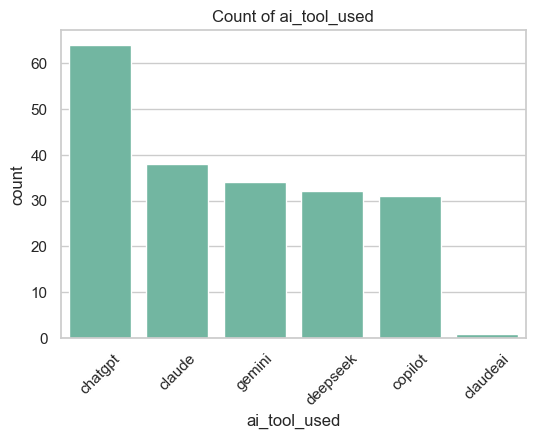

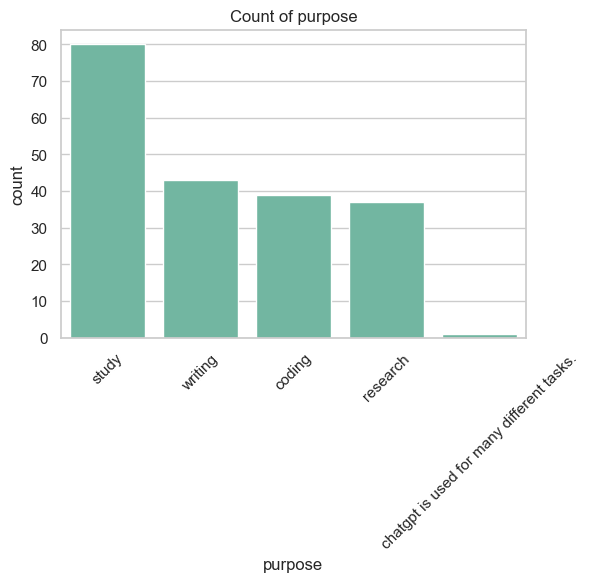

In [86]:
# Categorical feature analysis
for col in ['ai_tool_used', 'purpose']:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.show()

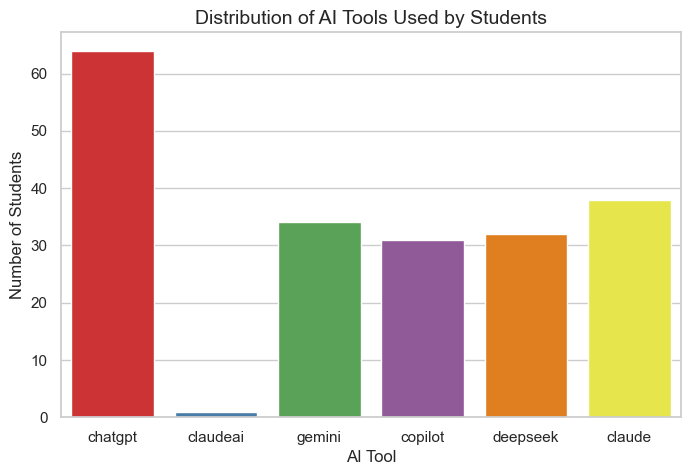

In [87]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='ai_tool_used',
    palette='Set1'
)

plt.title("Distribution of AI Tools Used by Students", fontsize=14)
plt.xlabel("AI Tool")
plt.ylabel("Number of Students")
plt.show()

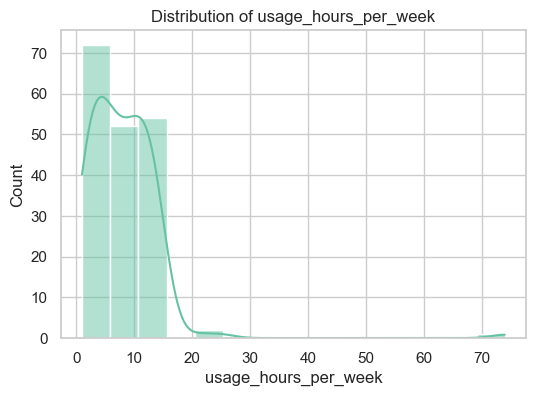

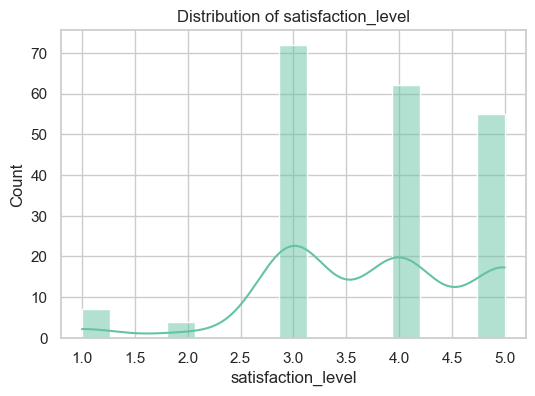

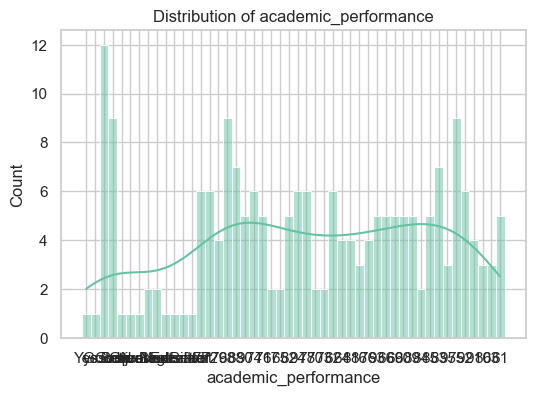

In [88]:
# Numeric feature distributions
numeric_cols = ['usage_hours_per_week', 'satisfaction_level', 'academic_performance']
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=15)
    plt.title(f'Distribution of {col}')
    plt.show()

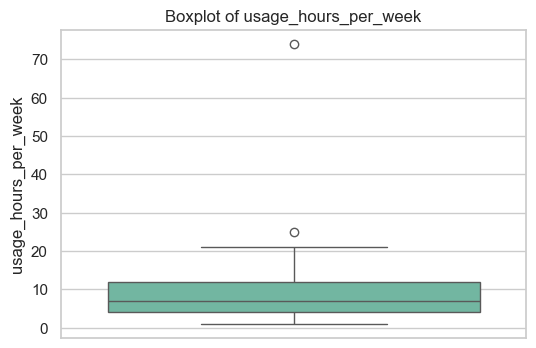

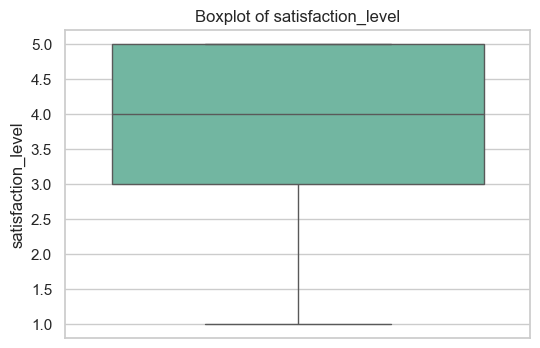

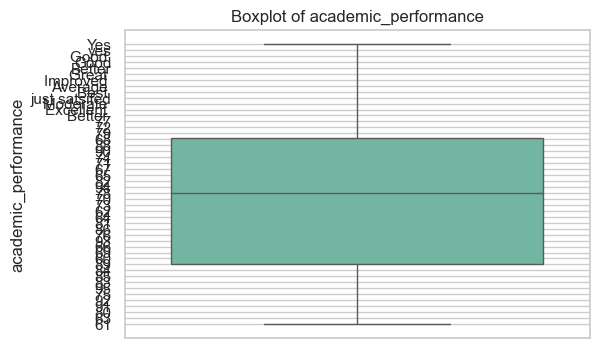

In [89]:
#  Boxplots to find outliers
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

## 4) Visualization (Advanced)

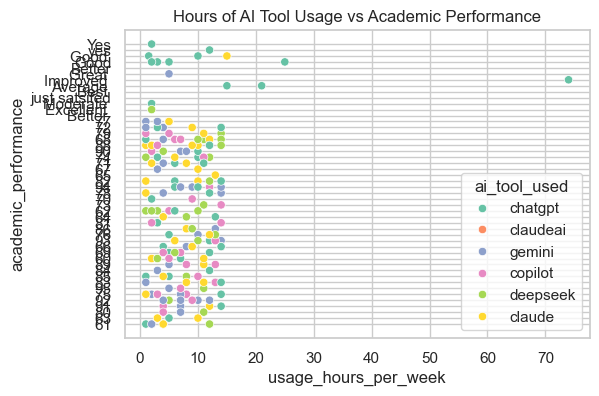

In [90]:
# Scatter plot: usage_hours vs academic_performance
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='usage_hours_per_week', y='academic_performance', hue='ai_tool_used')
plt.title('Hours of AI Tool Usage vs Academic Performance')
plt.show()

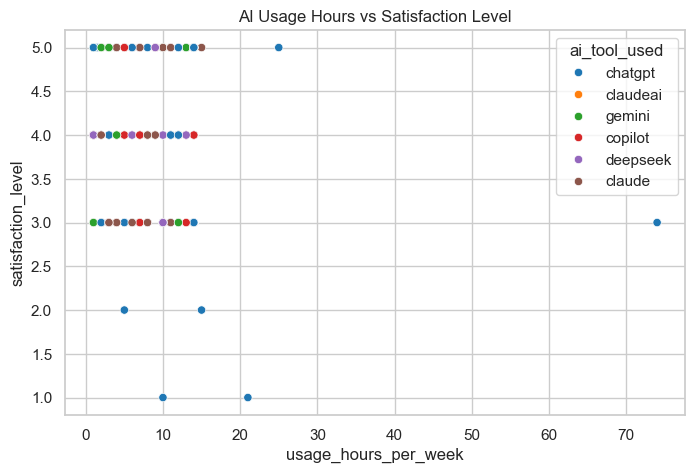

In [91]:
#  Scatter Plot (Usage vs Performance)
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="usage_hours_per_week",
    y="satisfaction_level",
    hue="ai_tool_used",
    palette="tab10"
)

plt.title("AI Usage Hours vs Satisfaction Level")
plt.show()

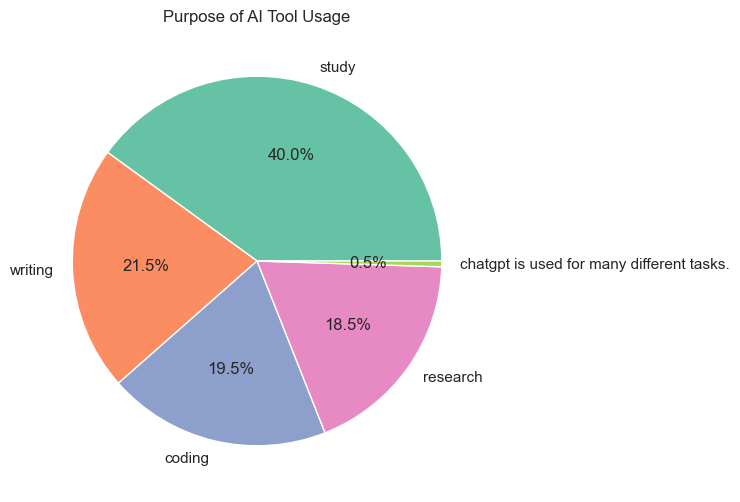

In [92]:
# Pie chart: purpose distribution
df['purpose'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6,6))
plt.title('Purpose of AI Tool Usage')
plt.ylabel('')
plt.show()

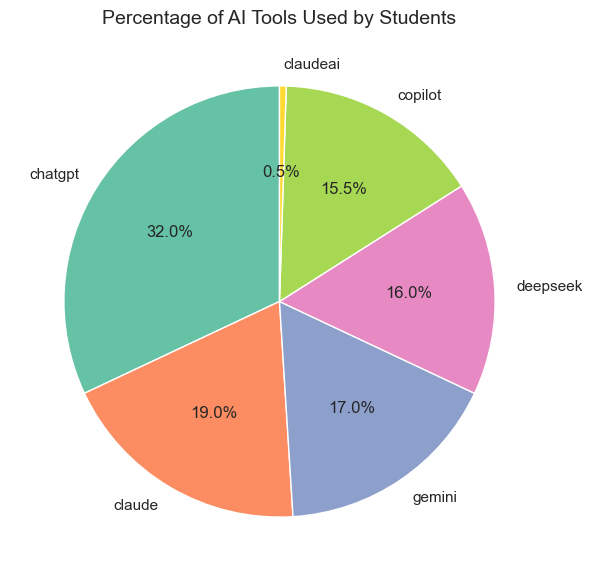

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count AI tool usage
tool_counts = df['ai_tool_used'].value_counts()

# Create pie chart
plt.figure(figsize=(7,7))

plt.pie(
    tool_counts,
    labels=tool_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("Set2")
)

plt.title("Percentage of AI Tools Used by Students", fontsize=14)
plt.show()

## 5) Simple ML Model: Predict Academic Performance

We will build a simple model to predict `academic_performance_clean` using available features.

Steps:
1. Encode categorical variables
2. Define features and target
3. Split into train/test sets
4. Train the Random Forest Classifier
5. Evaluate using accuracy and confusion matrix

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [95]:
# Encode categorical variables
le = LabelEncoder()

df['ai_tool_used'] = le.fit_transform(df['ai_tool_used'])
df['purpose'] = le.fit_transform(df['purpose'])
df['academic_performance'] = le.fit_transform(df['academic_performance'])

In [96]:
#  Define features and target
X = df[['ai_tool_used', 'usage_hours_per_week', 'satisfaction_level', 'purpose']]
y = df['academic_performance']

In [97]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [98]:
# Train the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [99]:
# Make predictions
y_pred = model.predict(X_test)

In [100]:
#  Evaluate Model
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.05


In [101]:
# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 1 1 0]
 [0 0 0 ... 0 0 0]]


In [102]:
# Detailed Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       1.00      0.50      0.67         2
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         2
          11       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         2
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         2
          16       0.00      0.00      0.00         0
          17       0.00      0.00      0.00         1
          18       0.00      0.00      0.00         0
          19       0.00      0.00      0.00         0
          20       0.00    

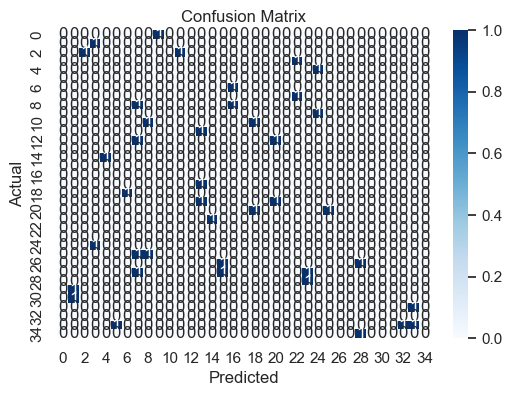

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 6) Summary and Key Insights

### Dataset Summary

This project analyzed student usage of AI tools for academic purposes. The dataset was cleaned, ensuring consistent categories and correct data types.

- EDA and Visualizations:
Bar charts, pie charts, histograms, scatter plots, and a heatmap were used to explore patterns in tool usage, purpose, weekly usage hours, and satisfaction levels.

- Machine Learning:
A Random Forest Classifier predicted academic performance using features like AI tool, usage hours, satisfaction, and purpose. Model performance was evaluated with accuracy and a confusion matrix.

### Key Insights:

Some AI tools are more popular than others.

Usage patterns vary by purpose and satisfaction.

ML provides insights into factors affecting academic performance.

### Conclusion:
The analysis highlights trends in AI tool usage and demonstrates how visualization and ML can reveal meaningful patterns in student behavior.
"""